# MarketLens Stage 5: Dashboard Data Test

This notebook tests the charts and tables that will later be used in the Streamlit dashboard.

Input:
- `data/processed/marketlens_features.csv`

Output:
- `reports/dashboard_data_test_check.txt`

Charts tested:
- SPY close price
- Moving averages
- Cumulative return
- Drawdown
- RSI 14
- DGS10 10-Year Treasury yield
- Correlation table

#### Imports and project root

In [1]:
from pathlib import Path
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

PROJECT_ROOT = Path(r"C:\Users\Wilson\Documents\OpenAI\MarketLens")
os.chdir(PROJECT_ROOT)

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
REPORTS_DIR = PROJECT_ROOT / "reports"

REPORTS_DIR.mkdir(parents=True, exist_ok=True)

print("Current working directory:")
print(Path.cwd())

print("\nProcessed data folder:")
print(PROCESSED_DIR)

Current working directory:
C:\Users\Wilson\Documents\OpenAI\MarketLens

Processed data folder:
C:\Users\Wilson\Documents\OpenAI\MarketLens\data\processed


#### Load feature dataset

In [3]:
features_path = PROCESSED_DIR / "marketlens_features.csv"

if not features_path.exists():
    raise FileNotFoundError(f"Missing file: {features_path}")

df = pd.read_csv(features_path)

print("Dataset shape:", df.shape)
print("Columns:")
print(df.columns.tolist())

display(df.head())
display(df.tail())

Dataset shape: (2136, 17)
Columns:
['date', 'open', 'high', 'low', 'close', 'adj_close', 'volume', 'dgs10', 'daily_return', 'cumulative_return', 'moving_average_20', 'moving_average_50', 'rolling_volatility_20', 'rsi_14', 'running_max_close', 'drawdown', 'trend_status']


,date,open,high,low,close,adj_close,volume,dgs10,daily_return,cumulative_return,moving_average_20,moving_average_50,rolling_volatility_20,rsi_14,running_max_close,drawdown,trend_status
0,2018-01-02,267.839996,268.809998,267.399994,268.769989,235.954208,86655700,2.46,NaN,0.000000,NaN,NaN,NaN,NaN,268.769989,0.0,Insufficient data
1,2018-01-03,268.959991,270.640015,268.959991,270.470001,237.446716,90070400,2.44,0.006325,0.006325,NaN,NaN,NaN,NaN,270.470001,0.0,Insufficient data
2,2018-01-04,271.200012,272.160004,270.540009,271.609985,238.447495,80636400,2.46,0.004215,0.010567,NaN,NaN,NaN,NaN,271.609985,0.0,Insufficient data
3,2018-01-05,272.510010,273.559998,271.950012,273.420013,240.036560,83524000,2.47,0.006664,0.017301,NaN,NaN,NaN,NaN,273.420013,0.0,Insufficient data
4,2018-01-08,273.309998,274.100006,272.980011,273.920013,240.475525,57319200,2.49,0.001829,0.019161,NaN,NaN,NaN,NaN,273.920013,0.0,Insufficient data


,date,open,high,low,close,adj_close,volume,dgs10,daily_return,cumulative_return,moving_average_20,moving_average_50,rolling_volatility_20,rsi_14,running_max_close,drawdown,trend_status
2131,2026-06-26,728.950012,736.530029,716.580017,728.989990,728.989990,71034000,4.38,-0.007231,1.712319,743.601999,734.351400,0.167221,44.927706,759.570007,-0.040260,Below 50-day average
2132,2026-06-29,736.530029,741.559998,732.090027,741.000000,741.000000,58035200,4.38,0.016475,1.757004,742.828000,735.138201,0.178805,50.939627,759.570007,-0.024448,Above 50-day average
2133,2026-06-30,741.289978,748.020020,740.890015,746.770020,746.770020,55626000,4.44,0.007787,1.778472,742.239502,735.870801,0.181082,54.943059,759.570007,-0.016852,Above 50-day average
2134,2026-07-01,745.000000,749.440002,742.380005,745.760010,745.760010,47100900,4.48,-0.001353,1.774715,741.549002,736.611602,0.180925,61.589335,759.570007,-0.018181,Above 50-day average
2135,2026-07-02,747.400024,751.309998,740.030029,744.780029,744.780029,57447800,4.48,-0.001314,1.771068,741.076004,737.425602,0.179475,54.596661,759.570007,-0.019472,Above 50-day average


#### Prepare dashboard dataset

In [4]:
df = df.copy()

df["date"] = pd.to_datetime(df["date"], errors="coerce")

numeric_cols = [
    "open",
    "high",
    "low",
    "close",
    "adj_close",
    "volume",
    "dgs10",
    "daily_return",
    "cumulative_return",
    "moving_average_20",
    "moving_average_50",
    "rolling_volatility_20",
    "rsi_14",
    "drawdown",
]

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(subset=["date", "close"])
df = df.sort_values("date").reset_index(drop=True)

print("Prepared dashboard dataset shape:", df.shape)
display(df.head())

Prepared dashboard dataset shape: (2136, 17)


,date,open,high,low,close,adj_close,volume,dgs10,daily_return,cumulative_return,moving_average_20,moving_average_50,rolling_volatility_20,rsi_14,running_max_close,drawdown,trend_status
0,2018-01-02,267.839996,268.809998,267.399994,268.769989,235.954208,86655700,2.46,NaN,0.000000,NaN,NaN,NaN,NaN,268.769989,0.0,Insufficient data
1,2018-01-03,268.959991,270.640015,268.959991,270.470001,237.446716,90070400,2.44,0.006325,0.006325,NaN,NaN,NaN,NaN,270.470001,0.0,Insufficient data
2,2018-01-04,271.200012,272.160004,270.540009,271.609985,238.447495,80636400,2.46,0.004215,0.010567,NaN,NaN,NaN,NaN,271.609985,0.0,Insufficient data
3,2018-01-05,272.510010,273.559998,271.950012,273.420013,240.036560,83524000,2.47,0.006664,0.017301,NaN,NaN,NaN,NaN,273.420013,0.0,Insufficient data
4,2018-01-08,273.309998,274.100006,272.980011,273.920013,240.475525,57319200,2.49,0.001829,0.019161,NaN,NaN,NaN,NaN,273.920013,0.0,Insufficient data


#### Dashboard summary metrics

In [5]:
latest = df.dropna(subset=["close"]).iloc[-1]

summary_metrics = {
    "latest_date": latest["date"],
    "latest_close": latest["close"],
    "latest_daily_return": latest.get("daily_return", np.nan),
    "latest_cumulative_return": latest.get("cumulative_return", np.nan),
    "latest_rolling_volatility_20": latest.get("rolling_volatility_20", np.nan),
    "latest_rsi_14": latest.get("rsi_14", np.nan),
    "latest_drawdown": latest.get("drawdown", np.nan),
    "latest_dgs10": latest.get("dgs10", np.nan),
    "latest_trend_status": latest.get("trend_status", "Insufficient data"),
}

summary_table = pd.DataFrame(summary_metrics.items(), columns=["metric", "value"])

display(summary_table)

,metric,value
0,latest_date,2026-07-02 00:00:00
1,latest_close,744.780029
2,latest_daily_return,-0.001314
3,latest_cumulative_return,1.771068
4,latest_rolling_volatility_20,0.179475
5,latest_rsi_14,54.596661
6,latest_drawdown,-0.019472
7,latest_dgs10,4.48
8,latest_trend_status,Above 50-day average


#### Plotly price and moving average chart

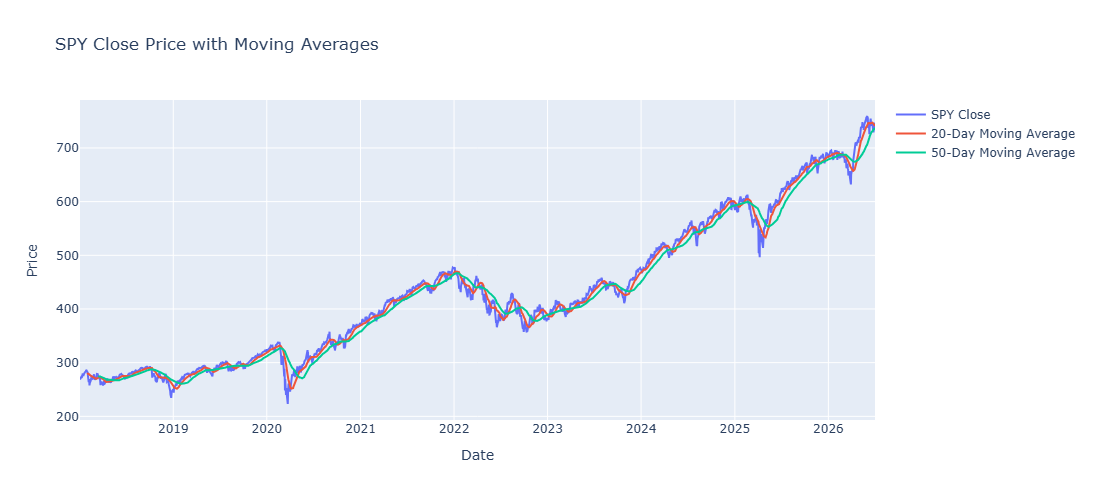

In [6]:
fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=df["date"],
        y=df["close"],
        mode="lines",
        name="SPY Close"
    )
)

fig.add_trace(
    go.Scatter(
        x=df["date"],
        y=df["moving_average_20"],
        mode="lines",
        name="20-Day Moving Average"
    )
)

fig.add_trace(
    go.Scatter(
        x=df["date"],
        y=df["moving_average_50"],
        mode="lines",
        name="50-Day Moving Average"
    )
)

fig.update_layout(
    title="SPY Close Price with Moving Averages",
    xaxis_title="Date",
    yaxis_title="Price",
    height=500
)

fig.show()

#### Cumulative return chart

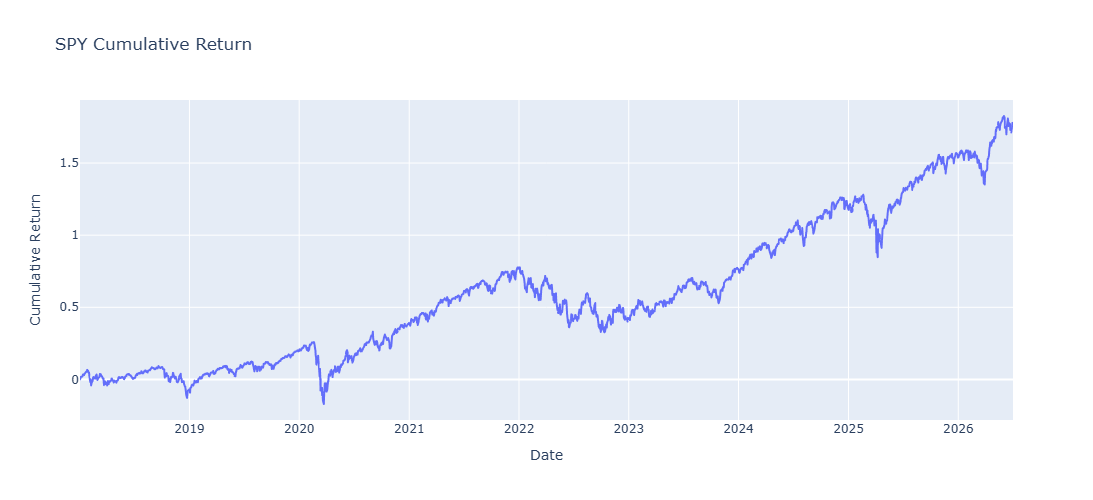

In [8]:
fig = px.line(
    df,
    x="date",
    y="cumulative_return",
    title="SPY Cumulative Return"
)

fig.update_layout(
    xaxis_title="Date",
    yaxis_title="Cumulative Return",
    height=500
)

fig.show()

#### Drawdown chart

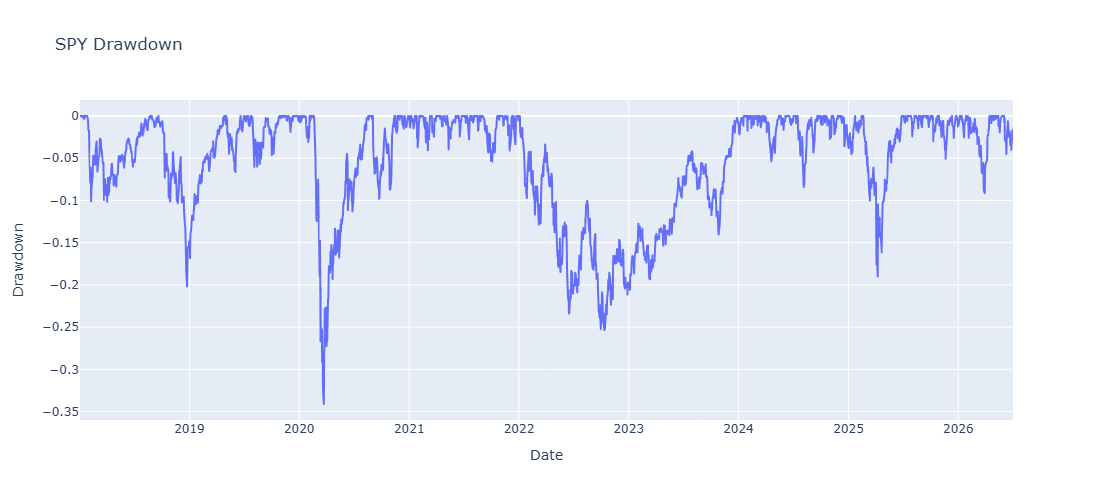

In [10]:
fig = px.line(
    df,
    x="date",
    y="drawdown",
    title="SPY Drawdown"
)

fig.update_layout(
    xaxis_title="Date",
    yaxis_title="Drawdown",
    height=500
)

fig.show()

#### RSI chart

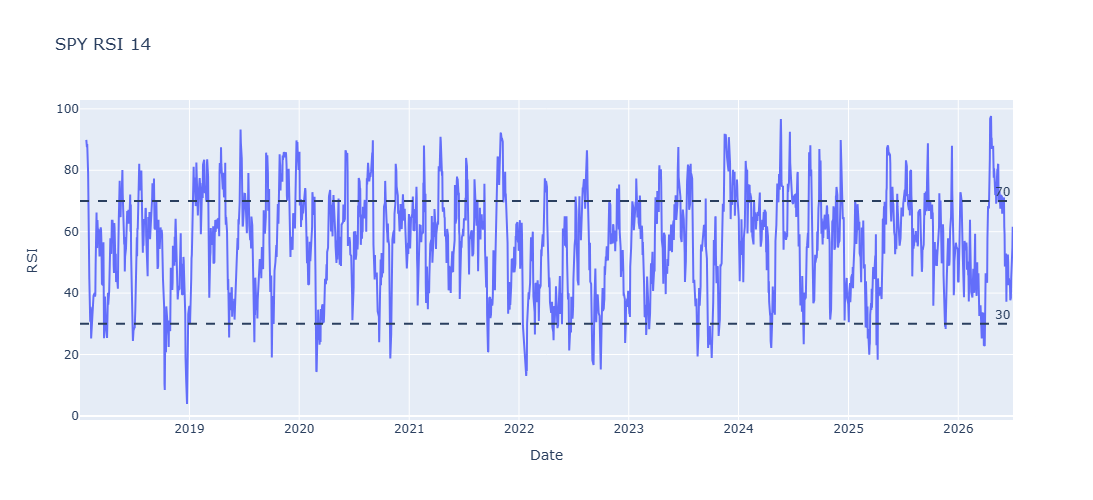

In [11]:
fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=df["date"],
        y=df["rsi_14"],
        mode="lines",
        name="RSI 14"
    )
)

fig.add_hline(y=70, line_dash="dash", annotation_text="70")
fig.add_hline(y=30, line_dash="dash", annotation_text="30")

fig.update_layout(
    title="SPY RSI 14",
    xaxis_title="Date",
    yaxis_title="RSI",
    height=500
)

fig.show()

#### DGS10 macro chart

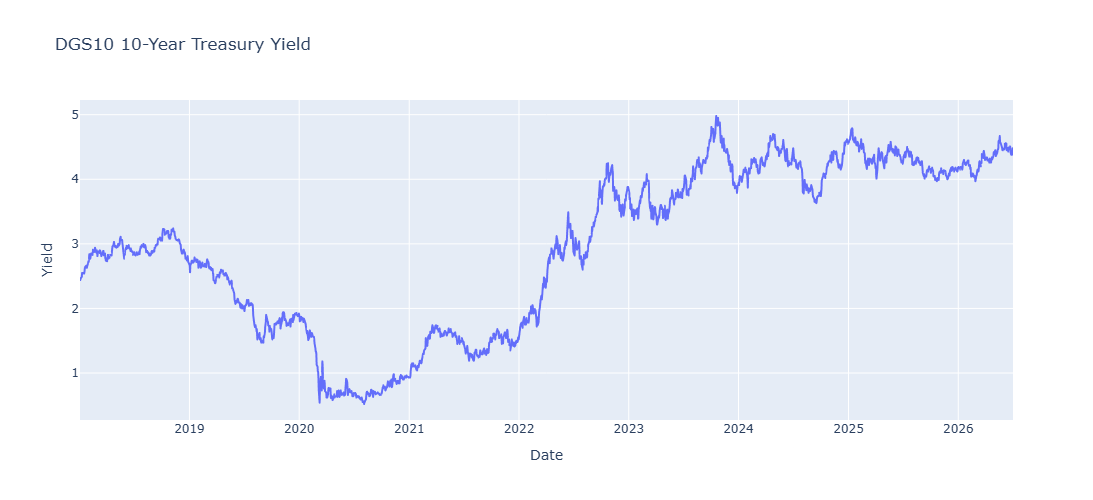

In [12]:
fig = px.line(
    df,
    x="date",
    y="dgs10",
    title="DGS10 10-Year Treasury Yield"
)

fig.update_layout(
    xaxis_title="Date",
    yaxis_title="Yield",
    height=500
)

fig.show()

#### Rolling volatility chart

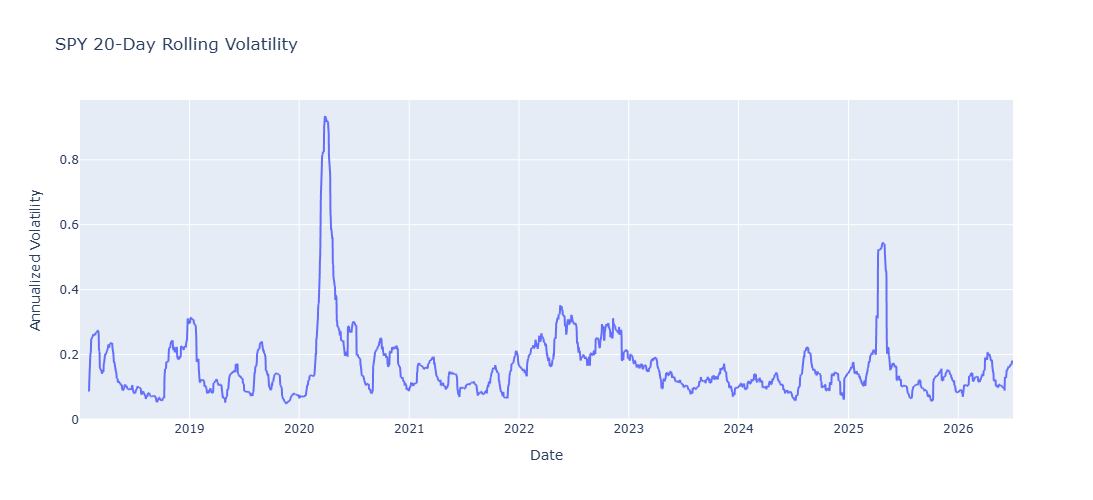

In [13]:
fig = px.line(
    df,
    x="date",
    y="rolling_volatility_20",
    title="SPY 20-Day Rolling Volatility"
)

fig.update_layout(
    xaxis_title="Date",
    yaxis_title="Annualized Volatility",
    height=500
)

fig.show()

#### Correlation check

In [14]:
corr_cols = [
    "daily_return",
    "rolling_volatility_20",
    "rsi_14",
    "drawdown",
    "dgs10",
]

available_corr_cols = [col for col in corr_cols if col in df.columns]

correlation_table = df[available_corr_cols].corr().round(3)

display(correlation_table)

,daily_return,rolling_volatility_20,rsi_14,drawdown,dgs10
daily_return,1.000,0.026,0.212,0.109,-0.003
rolling_volatility_20,0.026,1.000,-0.250,-0.663,-0.205
rsi_14,0.212,-0.250,1.000,0.408,-0.037
drawdown,0.109,-0.663,0.408,1.000,-0.030
dgs10,-0.003,-0.205,-0.037,-0.030,1.000


#### Dashboard readiness checks

In [15]:
required_dashboard_columns = [
    "date",
    "close",
    "daily_return",
    "cumulative_return",
    "moving_average_20",
    "moving_average_50",
    "rolling_volatility_20",
    "rsi_14",
    "drawdown",
    "trend_status",
    "dgs10",
]

readiness_results = []

for col in required_dashboard_columns:
    readiness_results.append({
        "column": col,
        "exists": col in df.columns,
        "missing_values": int(df[col].isna().sum()) if col in df.columns else None,
        "missing_percent": round(float(df[col].isna().mean() * 100), 2) if col in df.columns else None
    })

readiness_table = pd.DataFrame(readiness_results)

display(readiness_table)

,column,exists,missing_values,missing_percent
0,date,True,0,0.00
1,close,True,0,0.00
2,daily_return,True,1,0.05
3,cumulative_return,True,0,0.00
4,moving_average_20,True,19,0.89
5,moving_average_50,True,49,2.29
6,rolling_volatility_20,True,20,0.94
7,rsi_14,True,14,0.66
8,drawdown,True,0,0.00
9,trend_status,True,0,0.00


#### Save dashboard test report

In [16]:
from datetime import datetime

report_path = REPORTS_DIR / "dashboard_data_test_check.txt"

report = f"""
MarketLens Dashboard Data Test Check

Status: Dashboard data test completed.
Timestamp: {datetime.now()}

Input file:
- data/processed/marketlens_features.csv

Charts tested:
- SPY close price with moving averages
- Cumulative return
- Drawdown
- RSI 14
- DGS10 10-Year Treasury yield
- Rolling volatility

Latest metrics:
{summary_table.to_string(index=False)}

Correlation table:
{correlation_table.to_string()}

Dashboard readiness:
{readiness_table.to_string(index=False)}

Note:
This dataset and dashboard are for educational and portfolio demonstration only. They do not prove that any trading or investment strategy is profitable.
"""

report_path.write_text(report.strip(), encoding="utf-8")

print(f"Report saved to: {report_path}")

Report saved to: C:\Users\Wilson\Documents\OpenAI\MarketLens\reports\dashboard_data_test_check.txt
